# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test1 density

Notebook equivalent of `tests/4_earth/test1_density.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test1_density"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test1_density.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test1_density


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_density_file_exists`

**What is checked:** Density file exists behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_density_file_exists)


Running test_density_file_exists ...
Checking density file: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\density\earth_density.csv
------------------------------------------------------------------------------------------
PASSED: test_density_file_exists


## Test: `test_density_loads_correctly`

**What is checked:** Density loads correctly behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: rj must be 1D; alpha shape mismatch; beta shape mismatch; gamma shape mismatch; and additional consistency checks.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_density_loads_correctly)


Running test_density_loads_correctly ...

Loaded earth density object:
rj shape     : torch.Size([5])
alpha shape  : torch.Size([5])
beta shape   : torch.Size([5])
gamma shape  : torch.Size([5])
deltas shape : torch.Size([0, 5])
Test Device  : cuda:0
device       : cuda:0
dtype        : torch.float64
------------------------------------------------------------------------------------------
PASSED: test_density_loads_correctly


## Test: `test_shell_radii_are_valid`

**What is checked:** Shell radii are valid behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: rj contains NaN or Inf; rj must be >= 0; rj must be <= 1; rj must be sorted increasingly.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_shell_radii_are_valid)


Running test_shell_radii_are_valid ...

Shell radii rj:
tensor([1.9200000000e-01, 5.4600000000e-01, 8.9500000000e-01, 9.3700000000e-01, 1.0000000000e+00], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_shell_radii_are_valid


## Test: `test_shell_crossings_scalar_eta`

**What is checked:** Shell crossings scalar eta behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: xj shape mismatch; crossed shape mismatch; idx0 should be scalar; xj contains NaN or Inf.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_shell_crossings_scalar_eta)


Running test_shell_crossings_scalar_eta ...

Scalar eta shell crossings:
eta     : 0.4
xj shape: torch.Size([5])
crossed : tensor([False,  True,  True,  True,  True], device='cuda:0')
idx0    : tensor(1, device='cuda:0')
xj      : tensor([0.0000000000e+00, 3.8271314933e-01, 8.0584015454e-01, 8.5224547794e-01, 9.2106099400e-01], device='cuda:0', dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_shell_crossings_scalar_eta


## Test: `test_shell_crossings_batched_eta`

**What is checked:** Shell crossings batched eta behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: batched xj shape mismatch; batched crossed shape mismatch; batched idx0 shape mismatch; batched xj contains NaN or Inf.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_shell_crossings_batched_eta)


Running test_shell_crossings_batched_eta ...

Batched eta shell crossings:
eta shape    : torch.Size([8])
xj shape     : torch.Size([8, 5])
crossed shape: torch.Size([8, 5])
idx0 shape   : torch.Size([8])
------------------------------------------------------------------------------------------
PASSED: test_shell_crossings_batched_eta


## Test: `test_parameters_abc_shapes`

**What is checked:** Parameters abc shapes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: coeffs_abc shape mismatch; xj shape mismatch; crossed shape mismatch; coeffs_abc contains NaN or Inf.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [9]:
run_notebook_test(TEST_MODULE.test_parameters_abc_shapes)


Running test_parameters_abc_shapes ...

parameters_abc:
eta shape        : torch.Size([4])
coeffs_abc shape : torch.Size([4, 5, 3])
xj shape         : torch.Size([4, 5])
crossed shape    : torch.Size([4, 5])
------------------------------------------------------------------------------------------
PASSED: test_parameters_abc_shapes


## Test: `test_full_parameters_shapes`

**What is checked:** Full parameters shapes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: full parameters shape mismatch; full parameters contains NaN or Inf.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [10]:
run_notebook_test(TEST_MODULE.test_full_parameters_shapes)


Running test_full_parameters_shapes ...

parameters:
coeffs shape : torch.Size([3, 5, 3])
expected     : (3, 5, 3)
------------------------------------------------------------------------------------------
PASSED: test_full_parameters_shapes


## Test: `test_density_x_eta_values_are_finite`

**What is checked:** Density x eta values are finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: density_x_eta shape mismatch; density_x_eta contains NaN or Inf; density should be non-negative up to numerical tolerance.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [11]:
run_notebook_test(TEST_MODULE.test_density_x_eta_values_are_finite)


Running test_density_x_eta_values_are_finite ...

density_x_eta:
x shape  : torch.Size([200])
ne shape : torch.Size([200])
min ne   : 0.0
max ne   : 5.224060382950508
------------------------------------------------------------------------------------------
PASSED: test_density_x_eta_values_are_finite


## Test: `test_density_call_wrapper`

**What is checked:** Density call wrapper behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_close.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [12]:
run_notebook_test(TEST_MODULE.test_density_call_wrapper)


Running test_density_call_wrapper ...

density call wrappers:
density_x_eta: 2.6956943733522616
call         : 2.6956943733522616
__call__     : 2.6956943733522616
------------------------------------------------------------------------------------------
PASSED: test_density_call_wrapper


## Plot: `plot_radial_density_profile()`

**What is checked:** Radial density profile behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_density_profile_r.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_radial_density_profile()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_density_profile_r.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_radial_density_profile() ...
Saved plot: V:\output\test\earth\test1_density\plot_radial_density_profile_figure_001.png


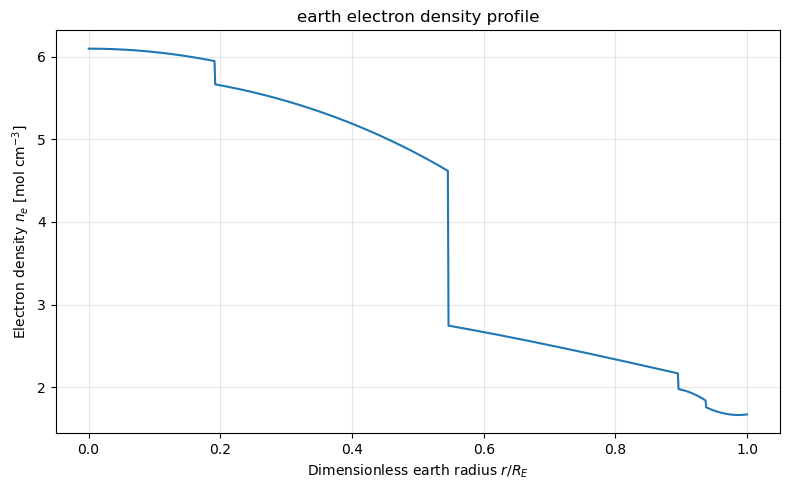

PASSED: plot_radial_density_profile()


In [13]:
run_notebook_call('plot_radial_density_profile()', lambda: TEST_MODULE.plot_radial_density_profile())


## Plot: `plot_density_along_trajectories()`

**What is checked:** Density along trajectories behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_density_x_eta.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_density_along_trajectories()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_density_x_eta.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_density_along_trajectories() ...
Saved plot: V:\output\test\earth\test1_density\plot_density_along_trajectories_figure_001.png


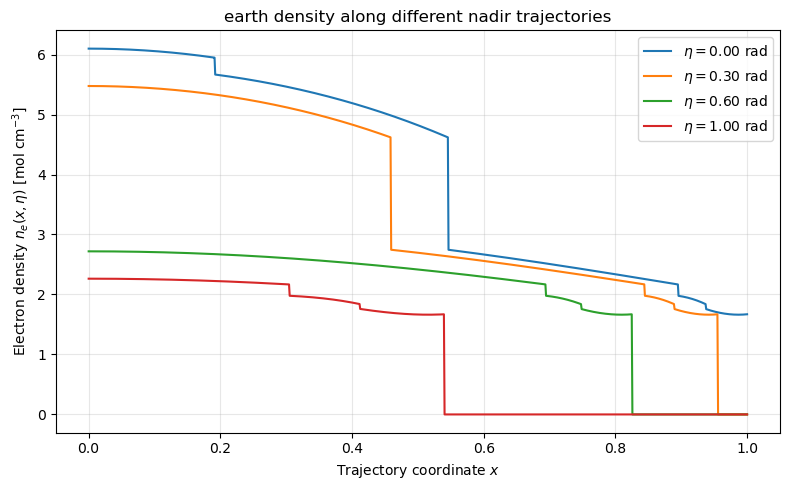

PASSED: plot_density_along_trajectories()


In [14]:
run_notebook_call('plot_density_along_trajectories()', lambda: TEST_MODULE.plot_density_along_trajectories())


## Plot: `plot_shell_crossings()`

**What is checked:** Shell crossings behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_shell_crossings.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_shell_crossings()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_shell_crossings.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_shell_crossings() ...
Saved plot: V:\output\test\earth\test1_density\plot_shell_crossings_figure_001.png


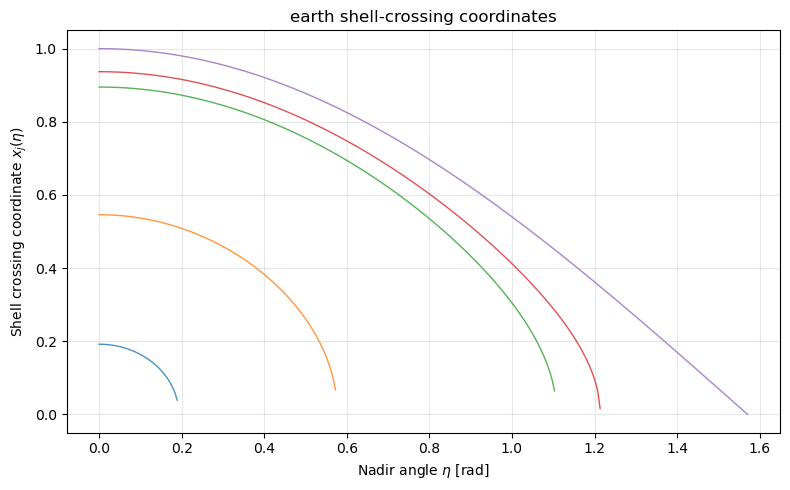

PASSED: plot_shell_crossings()


In [15]:
run_notebook_call('plot_shell_crossings()', lambda: TEST_MODULE.plot_shell_crossings())
